In [278]:
import numpy as np
import healpy as hp
from matplotlib import pyplot as plt

import pymaster as nmt
import sys
sys.path.append('../')
from scripts.simulate_planck_maps import simulate_planck_maps
from scripts.compute_cl import compute_cl
from scripts.compute_weights import compute_weights
from scripts.compute_alm_ilc import compute_alm_ilc
from scripts.compute_decoupled_cl import compute_decoupled_cl
# from scripts.compute_decoupled_cl_2 import compute_decoupled_cl_2
from scripts.mask_maps import mask_maps
from scripts.cosine_smoothed_mask import cosine_smoothed_mask

%matplotlib inline

Definitions

In [279]:
nside=128
npix=hp.nside2npix(nside=nside)
freq = np.array([28.4,  44.1,  70.4,  100.0,  143.0,  217.0,  353.0])
n_freqs = len(freq)

Simulate maps using PySM

In [280]:
noise, dust, sync, ff, cmb = simulate_planck_maps(nside,freq)

Combining the CMB and foreground maps to be input into ILC

In [281]:
maps_pl = cmb + noise + dust + sync + ff #cmb and foregrounds combined

Transforimng frequency maps to harmonic space by decomposition

In [282]:
#transform maps to spherical harmonics
lmax=2*nside #3*nside -1
alm_size=hp.Alm.getsize(lmax)
alm_maps=np.zeros((n_freqs, alm_size), dtype=complex) #storing coefficients in an array of dim n_freqs*almsize. dtype is complex to account for -ive values

for nf in range(n_freqs):
    alm_maps[nf,:]= hp.map2alm(maps_pl[nf,:], lmax=lmax, mmax=None, iter=0, pol=False) #record alm corresponding to each f for a corresponding l and m

Computing the angular power spectrum for the unmasked data

In [283]:
alm_p, C_l=compute_cl(alm_maps, lmax, n_freqs)

Using a cosine smoothed mask to make sure the smoothing accurately masks the emission on the galactic plane. It can be done using cosine smoothing.
Where we put the mask as:
 $$mask= \frac{1}{2} \Big( 1- \cos(\pi \frac{|b|-b_{min}}{b_{max}-b_{min}})\Big)$$

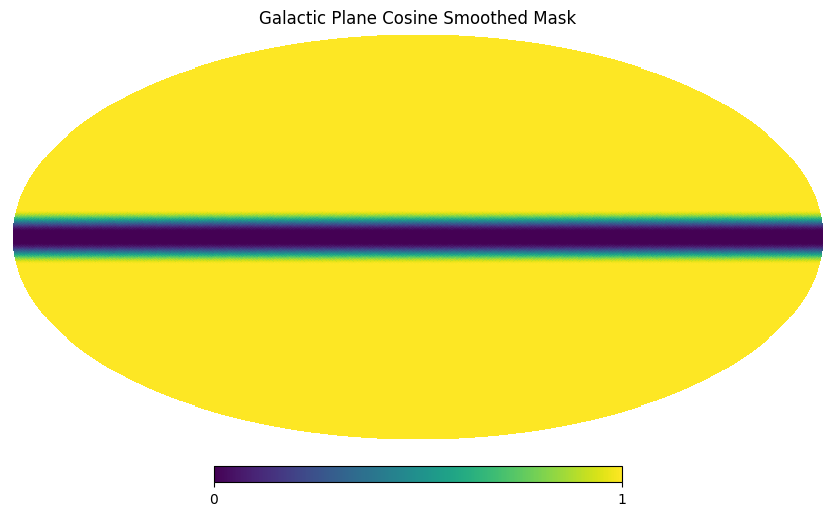

In [284]:
# Generate and plot the mask
mask2 = cosine_smoothed_mask(nside)
mask2= (mask2*(-1))+1
hp.mollview(1-mask2, title="Galactic Plane Cosine Smoothed Mask")

plt.show()

Decoupled power spectra $\hat{C_l^{ij}} = M_{ll'}^{-1} \tilde{C}_l^{ij}$

where $\tilde{C}_l^{ij}$ is the pseudo power spectrum aka the masked power spectrum

In [285]:
def compute_decoupled_cl_2( maps: np.ndarray, masks:np.ndarray, X:bool, nsides:int, l_max:int, n_freq:int)-> np.ndarray:
    """
    Compute the power spectra using NaMaster for a set of frequency maps.

    Parameters:
    - maps: numpy array of shape (n_freqs, n_maps) containing the frequency maps
    - masks: mask to apply to the maps
    - X: flag to indicate if the input maps are masked
    - nsides: resolution parameter for the maps
    - l_max: maximum multipole for the power spectra
    - n_freq: number of frequency channels

    Returns:
    - p_cl: raw power spectrum (coupled)
    - matrix: mode coupling matrix
    - cldec: decoupled power spectrum
    """
    p_cl =np.zeros((l_max+1, n_freq, n_freq))
    cldec = np.zeros((l_max+1, n_freq, n_freq))
    

    # Loop over all pairs of frequency maps (cross-power spectra)
    for i in range(n_freq):
        for j in range(i, n_freq):  # Compute only upper triangle (symmetric matrix)
            
            # Define the masked fields for the two maps
            f_i = nmt.NmtField(1 - masks, [maps[i, :]], masked_on_input=X, lmax=l_max) 
            f_j = nmt.NmtField(1 - masks, [maps[j, :]], masked_on_input=X, lmax=l_max) 
            
            if X==True:
                p_cl[:,i,j]= hp.anafast(maps[i,:], maps[j,:], lmax=l_max)
            else:
                
                # Compute the coupled power spectrum for (i, j)
                masked_map_i= (1-masks)*maps[i, :]
                masked_map_j= (1-masks)*maps[j,:]
                p_cl[:,i,j]= hp.anafast(masked_map_i, masked_map_j, lmax=l_max)
            
            # p_cl[:, i, j] = nmt.compute_coupled_cell(f_i, f_j)
            


            # Define a NaMaster binning scheme (no binning)
            b = nmt.NmtBin.from_lmax_linear(l_max, 1)

            # Create NaMaster workspace and get the coupling matrix
            w = nmt.NmtWorkspace.from_fields(f_i, f_j, b)
            #w = nmt.NmtWorkspace()
            w.compute_coupling_matrix(f_i, f_j, b)
        
            #w.compute(f_i, f_j, b)
            matrix = w.get_coupling_matrix() #lxl

            # Compute the inverse of the mode-coupling matrix
            matrix_inv = np.linalg.pinv(matrix, rcond=1e-6)

            # Compute the decoupled power spectrum using Einstein summation
            cldec[:, i, j] = np.einsum('ij,j->i', matrix_inv, p_cl[:, i, j])

            # Since Cl is symmetric, copy the value to (j, i)
            if i != j:
                cldec[:, j, i] = cldec[:, i, j]
                p_cl[:, j, i] = p_cl[:, i, j]
    return cldec

In [286]:
cl_dec=compute_decoupled_cl_2(maps_pl, mask2,False, nside, lmax, n_freqs)

In [287]:
print(cl_dec.shape)

(257, 7, 7)


Computing the decoupled power spectrum of the masked CMB map

In [288]:
cmb_dec= compute_decoupled_cl_2((1-mask2)*cmb, mask2,True, nside, lmax, n_freqs)
cmb_dec2= compute_decoupled_cl_2(cmb, mask2,False, nside, lmax, n_freqs)

In [289]:
print(cmb_dec.shape)

(257, 7, 7)


In [290]:
np.allclose(cmb_dec, cmb_dec2)

True

In [291]:
Cl_cmb = hp.anafast(cmb[0], lmax=lmax) #input cmb map

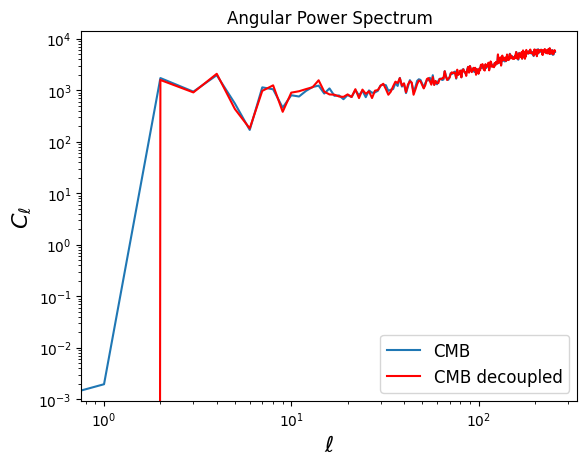

In [292]:
ells = np.arange(lmax+1)
norm = (ells * (ells + 1)) / (2 * np.pi)

plt.plot(ells, norm*Cl_cmb, label='CMB')
plt.plot(ells, norm*cmb_dec[:,0,0], 'r-',label= 'CMB decoupled')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.xscale("log")
plt.yscale("log")
plt.legend(fontsize=12)
plt.title("Angular Power Spectrum")
plt.show()

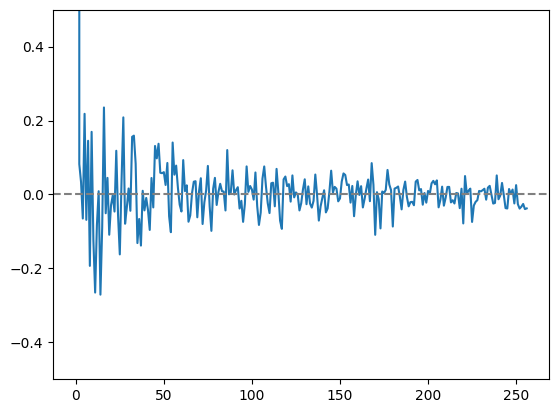

In [293]:
bias= (Cl_cmb- cmb_dec[:,0,0])/Cl_cmb
plt.plot(ells, bias)
# plt.xscale("log")
plt.ylim(-0.5,0.5)
plt.axhline(0, linestyle="--", color="gray")


Now we can compute the inverse covariance matrix and compute the weights using $$\omega_i(l) = \frac{\sum_j (C_l^{-1})_{ij} b_{j}}{\sum_{ij}b_i (C_l^{-1})_{ij} b_{j}}$$

where $b_i $ represents the CMB transfer function. $b_i = [1,...,1]$

In [294]:
cl_inv, weights = compute_weights(n_freqs, lmax, cl_dec)

Visualizing the weights

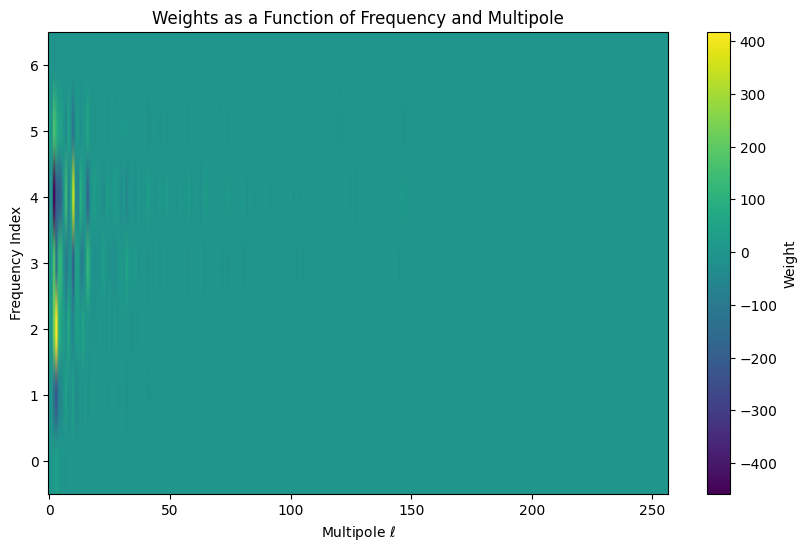

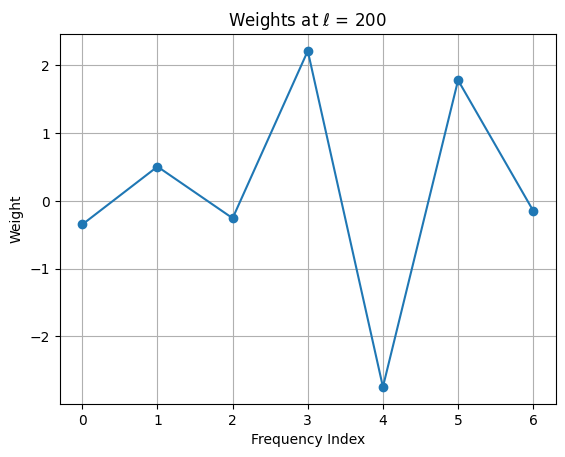

In [295]:
plt.figure(figsize=(10, 6))
plt.imshow(weights[:,:], aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label="Weight")
plt.xlabel("Multipole $\\ell$")
plt.ylabel("Frequency Index")
#plt.xlim(50,)
plt.title("Weights as a Function of Frequency and Multipole")
plt.show()


plt.plot(range(n_freqs), weights[:, 200], marker='o', linestyle='-')

plt.xlabel("Frequency Index")
plt.ylabel("Weight")
plt.title(f"Weights at $\\ell$ = {200}")
plt.grid()

Masking the data and converting the masked maps to harmonic space

In [296]:
maskfake= np.ones(mask2.size)

In [297]:
maps_masked, alm_masked= mask_maps(maps_pl, mask2, alm_size,lmax, n_freqs, npix)
print(maps_masked.shape)

(7, 196608)


Applying the weights to the masked data

$$a^{ILC}_{lm} = \sum_i w_i(l)a^i_{lm}$$

In [298]:
alm_ilc=compute_alm_ilc(alm_masked, alm_size, weights, lmax)
print(alm_ilc.shape)
print(alm_masked.shape)

(33153,)
(7, 33153)


In [299]:
np.allclose(alm_ilc, alm_masked)

False

In [300]:
test1= hp.alm2cl(alm_ilc)
test2= hp.alm2cl(alm_masked)
#test2.shape
np.allclose(test1, test2[0])

False

Converting back to pixel space

In [301]:
alm_masked.shape

(7, 33153)

In [302]:
maps_out = hp.alm2map(alm_ilc, nside, lmax)
# maps_masked_2 = hp.alm2map(alm_masked[0,:], nside, lmax)
#maybe get the decoupled alms
maps_out=np.tile(maps_out, (1, n_freqs))
maps_out = maps_out.reshape(n_freqs, npix)
print(maps_out.shape)

"""cl_out = hp.alm2cl(hp.map2alm(maps_out[0,:], lmax=lmax, mmax=None, iter=3, pol=False))
cl_masked_2 = hp.alm2cl(hp.map2alm(maps_masked, lmax=lmax, mmax=None, iter=3, pol=False))
ells = np.arange(lmax+1)
norm = (ells * (ells + 1)) / (2 * np.pi)
plt.plot(ells,norm*cl_out)
plt.plot(ells,norm*cl_masked_2[0,:])"""

(7, 196608)


'cl_out = hp.alm2cl(hp.map2alm(maps_out[0,:], lmax=lmax, mmax=None, iter=3, pol=False))\ncl_masked_2 = hp.alm2cl(hp.map2alm(maps_masked, lmax=lmax, mmax=None, iter=3, pol=False))\nells = np.arange(lmax+1)\nnorm = (ells * (ells + 1)) / (2 * np.pi)\nplt.plot(ells,norm*cl_out)\nplt.plot(ells,norm*cl_masked_2[0,:])'

In [303]:
np.allclose(maps_out, maps_masked)

False

Computing the angular power spectrum of the masked, component separated map

In [304]:
cl_hilc=compute_decoupled_cl_2(maps_out, mask2, True, nside, lmax, n_freqs) 
#for error ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.
#make sure to return ALL outputs of function

In [305]:
print(cl_hilc.shape)

(257, 7, 7)


In [306]:
np.allclose(cl_hilc, cmb_dec)
#should be true

False

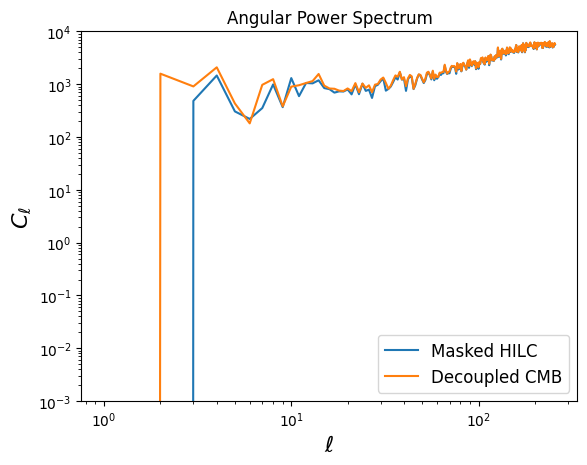

In [311]:
plt.plot(norm*cl_hilc[:,0,0], label='Masked HILC')
plt.plot(norm*cmb_dec[:,0,0], label='Decoupled CMB')
# plt.plot(norm*test1, label='Masked HILC')
# plt.plot(norm*test2[0,:], label='Decoupled CMB')

plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.xscale("log")
plt.yscale("log")
plt.ylim(1e-3,1e4)
plt.legend(fontsize=12)
plt.title("Angular Power Spectrum")
plt.show()

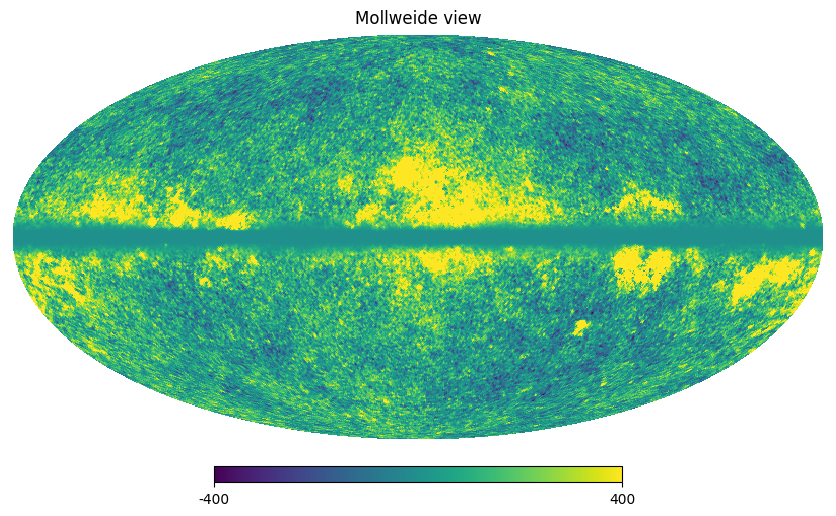

In [308]:
hp.mollview(maps_masked[0], min=-400, max=400)

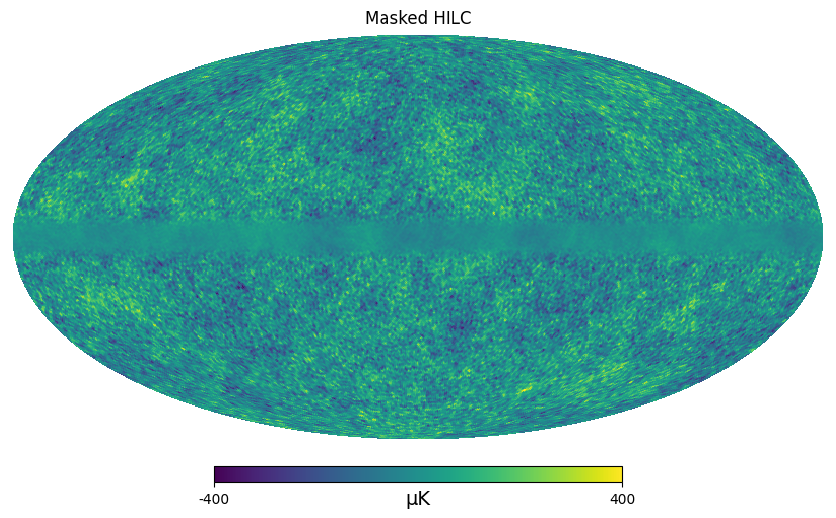

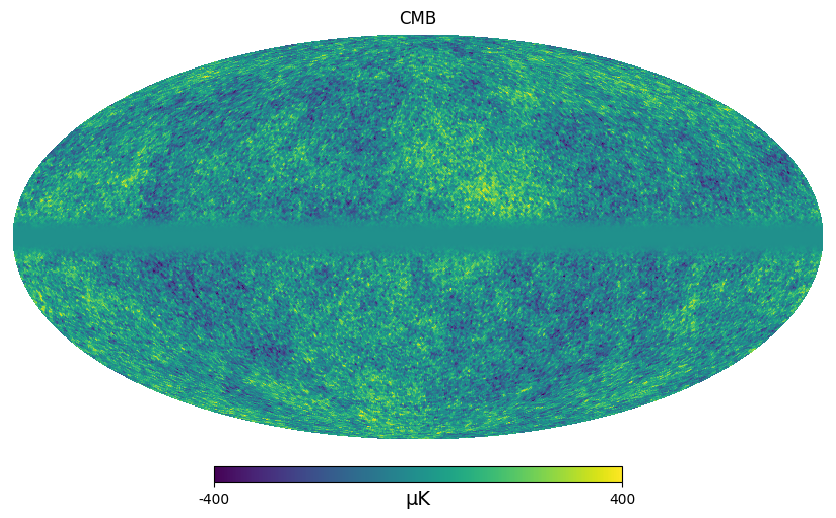

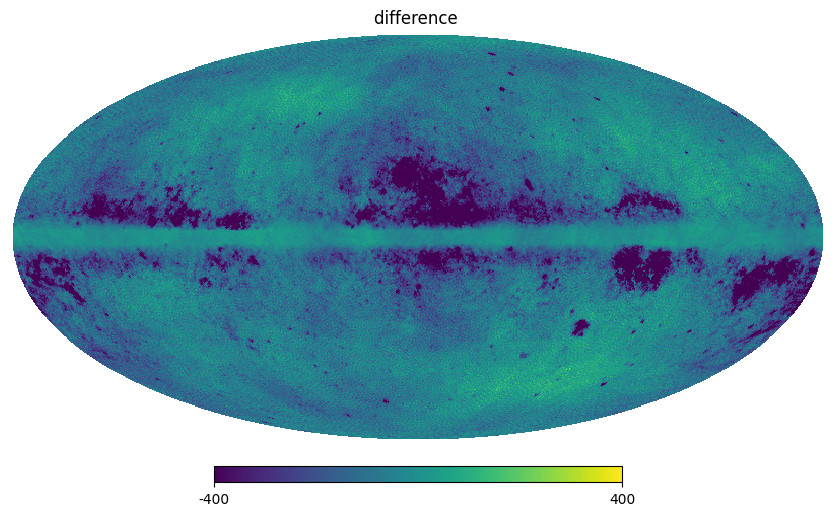

In [312]:

hp.mollview(maps_out[0], title= "Masked HILC", min=-400, max=400, unit="μK")
hp.mollview((1-mask2)*cmb[0],title ="CMB", min=-400, max=400, unit="μK")

hp.mollview(maps_out[0]- maps_masked[0], min=-400, max=400, title="difference ")

-----------------Extra Plots----------------

Compute the fractional difference between the two spectra:

$$
\text{frac\_diff}(\ell) = \frac{C_{\ell}^{\text{Decoupled}} - C_{\ell}^{\text{Input}}}{C_{\ell}^{\text{Input}}}
$$


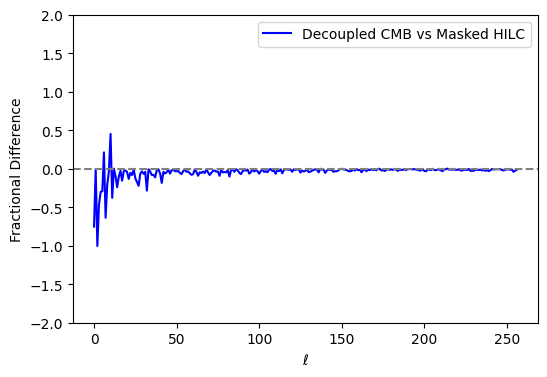

In [310]:
diff = (cl_hilc[:,0,0] - cmb_dec[:,0,0]) / cmb_dec [:,0,0]

plt.figure(figsize=(6, 4))
plt.plot(ells, diff, label="Decoupled CMB vs Masked HILC", color="blue")
plt.axhline(0, linestyle="--", color="gray")  # Reference line
#plt.yscale("log")
plt.ylim(-2, 2)
# plt.xscale("log")
plt.xlabel(r"$\ell$")
plt.ylabel(r"Fractional Difference")

plt.legend()
plt.show()
